In [2]:
import pandas as pd
import numpy as np
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
os.getcwd()
# 'C:\\Users\\gcart'

# set wooking directory
os.chdir('E:\\docs\\book_reviews\\manning\\solve_any_data_analysis_problem\\notebooks')
os.getcwd()
# 'C:\\Users\\gcart'

'E:\\docs\\book_reviews\\manning\\solve_any_data_analysis_problem\\notebooks'

In [4]:
# load data

traffic = pd.read_parquet("time_series.parquet.gz")
 
cycling = (
    traffic
    .groupby(["Count_point_id", "Year"])
    ["Pedal_cycles"]
    .sum()
    .reset_index()
)
 
cycling.head()
 

,Count_point_id,Year,Pedal_cycles
0,900056,2007,24
1,900056,2008,19
2,900056,2009,38
3,900056,2010,17
4,900056,2011,8


In [5]:
#  look at the distribution of the total number of bicycles seen per location ID across all years

cycling_totals = (
    cycling
    .groupby("Count_point_id")
    ["Pedal_cycles"]
    .sum()
)
 
cycling_totals.head()

Count_point_id
900056    259
919150    274
930188    133
931832    351
931837    102
Name: Pedal_cycles, dtype: int64

In [6]:
# understand the quartiles of these values to get a sense of what cutoff values would constitute the top 25% or 50% of the data

cycling_totals.describe()

count      691.000000
mean       455.458755
std       1090.329617
min          5.000000
25%        101.000000
50%        216.000000
75%        421.000000
max      19561.000000
Name: Pedal_cycles, dtype: float64

In [7]:
#  the most cycling traffic

cycling_totals.sort_values(ascending=False).head(10)

Count_point_id
942489    19561
942321     8542
944649     8344
942319     7932
941061     6668
946751     5319
942951     4468
942735     4439
942853     4427
945985     4034
Name: Pedal_cycles, dtype: int64

In [8]:
# take a single row of data and transpose it to show it as a single column

(
    traffic[traffic["Count_point_id"] == 942489]
    .head(1)
    .transpose()
)
 

,91722
Count_point_id,942489
Direction_of_travel,N
Year,2014
Count_date,2014-09-19 00:00:00
hour,7
Region_id,6
Region_name,London
Region_ons_code,E12000007
Local_authority_id,96
Local_authority_name,Islington


In [9]:
# Let’s see whether there were any major roads with over 1000 bikes seen in total

(
  traffic
  .merge(
    cycling_totals
      .reset_index()
      .rename(columns={
        "Pedal_cycles": "Total_cycles"
      }),
    on="Count_point_id"
  )
  .query("Total_cycles > 1000 and Road_type=='Major'")
)

,Count_point_id,Direction_of_travel,Year,Count_date,hour,Region_id,Region_name,Region_ons_code,Local_authority_id,Local_authority_name,...,LGVs,HGVs_2_rigid_axle,HGVs_3_rigid_axle,HGVs_4_or_more_rigid_axle,HGVs_3_or_4_articulated_axle,HGVs_5_articulated_axle,HGVs_6_articulated_axle,All_HGVs,All_motor_vehicles,Total_cycles


In [10]:
# lower that threshold to 100

bikes_100_plus = (
    traffic
    .merge(
        cycling_totals
            .reset_index()
            .rename(columns={"Pedal_cycles": "Total_cycles"}),
        on="Count_point_id"
    )
    .query("Total_cycles > 100 and Road_type=='Major'")
)
 
bikes_100_plus

,Count_point_id,Direction_of_travel,Year,Count_date,hour,Region_id,Region_name,Region_ons_code,Local_authority_id,Local_authority_name,...,LGVs,HGVs_2_rigid_axle,HGVs_3_rigid_axle,HGVs_4_or_more_rigid_axle,HGVs_3_or_4_articulated_axle,HGVs_5_articulated_axle,HGVs_6_articulated_axle,All_HGVs,All_motor_vehicles,Total_cycles


In [11]:
# code calculates both absolute and percentage change between the first and last values for each location

# Define a function to calculate the difference between the first and last values encountered in a group
def cycling_diff(group):
    return group.values[-1] - group.values[0]

# Define a function to calculate the change as a percentage
def cycling_diff_pct(group):
    # Account for division-by-zero errors
    if group.values[0] == 0:
        return np.inf
    diff = group.values[-1] - group.values[0]
    return diff / group.values[0]
 
cycling_diffs = (
    cycling
    .sort_values(["Count_point_id", "Year"])
    .groupby("Count_point_id")
    # Apply these two functions to every location ID group
    .agg(
        diff=("Pedal_cycles",cycling_diff),
        diff_pct=("Pedal_cycles",cycling_diff_pct)
    )
)
 
cycling_diffs

,diff,diff_pct
Count_point_id,,
900056,-10,-0.416667
919150,-1,-0.083333
930188,-2,-0.400000
931832,-10,-0.526316
931837,2,0.666667
...,...,...
990173,23,0.425926
990546,-17,-0.944444
990551,4,0.173913


In [12]:
# ook at one of the locations and see if the raw data supports the change values we calculated

cycling[cycling["Count_point_id"] == 900056]

,Count_point_id,Year,Pedal_cycles
0,900056,2007,24
1,900056,2008,19
2,900056,2009,38
3,900056,2010,17
4,900056,2011,8
5,900056,2012,23
6,900056,2013,5
7,900056,2014,19
8,900056,2015,13
9,900056,2016,32


In [13]:
#  look at some of the highest increases in cycling traffic in percentage terms

biggest_diffs = (
    cycling_diffs
    [np.isinf(cycling_diffs["diff_pct"]) == False]
    .sort_values("diff_pct", ascending=False)
    .head(10)
)
 
biggest_diffs

,diff,diff_pct
Count_point_id,,
931883,29,29.000
990552,38,19.000
943399,139,17.375
944961,16,16.000
943595,14,14.000
947607,14,14.000
946565,24,12.000
946375,12,12.000
943535,21,10.500


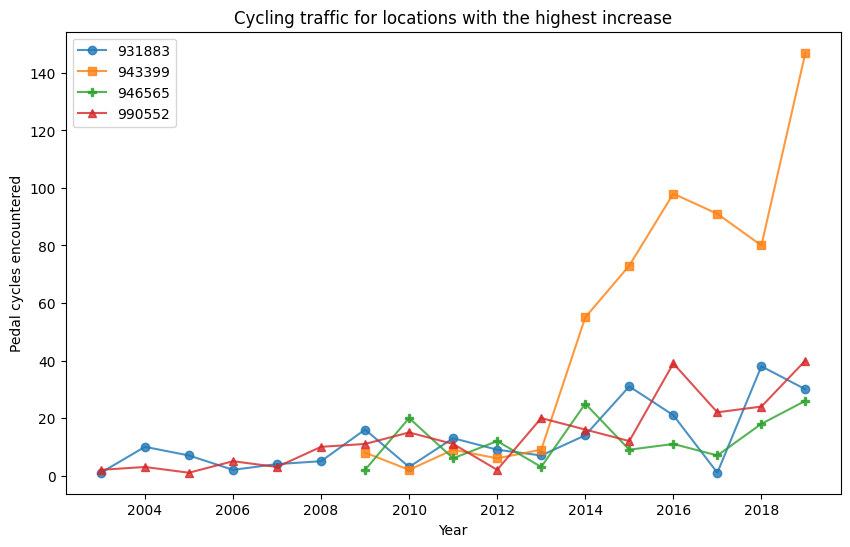

In [14]:
# plot these time series rather than relying on numeric calculations to determine interesting patterns

fig, axis = plt.subplots(figsize=(10, 6))
 
biggest_diff_ids = biggest_diffs.index
 
ids_to_plot = [943399, 931883, 946565, 990552]
 
diffs_to_plot = (
    cycling
    .query("Count_point_id in @ids_to_plot")
)
 
markers = ["o", "s", "P", "^"]
 
for i, point_id in enumerate(diffs_to_plot["Count_point_id"].unique()):
    point_series = cycling[cycling["Count_point_id"] == point_id]
    (
        point_series
        .set_index("Year")
        ["Pedal_cycles"]
        .plot(ax=axis,
              label=point_id,
              marker=markers[i],
              alpha=0.8)
    )
 
axis.set(
    xlabel="Year",
    ylabel="Pedal cycles encountered",
    title="Cycling traffic for locations with the highest increase"
)
 
axis.legend()
 
plt.show()

In [15]:
#  calculate cycling as a percentage of overall traffic.

annual_bike_traffic = (
    traffic
    [traffic['Count_date'] == traffic.groupby('Count_point_id')['Count_date'].transform('max')]
    .assign(
        all_traffic=lambda x: x["Pedal_cycles"] + x["All_motor_vehicles"]
    )
    .groupby(["Count_point_id", "Year"])
    [["Pedal_cycles", "all_traffic"]]
    .sum()
    .assign(
        pct_cycles = lambda x: x["Pedal_cycles"] / x["all_traffic"]
    )
    .sort_values("pct_cycles", ascending=False)
)
 
annual_bike_traffic.head()

,,Pedal_cycles,all_traffic,pct_cycles
Count_point_id,Year,,,
942489,2019,1748,2004.0,0.872255
945923,2019,352,522.0,0.674330
941061,2019,769,1466.0,0.524557
945955,2019,245,684.0,0.358187
944077,2019,64,183.0,0.349727


In [16]:
# investigate one of those examples in more detail.

(
  traffic[(traffic["Count_point_id"] == 942489) & (traffic["Year"] == 2019)]
  .head(1)
  .transpose()
)


,4337551
Count_point_id,942489
Direction_of_travel,S
Year,2019
Count_date,2019-09-20 00:00:00
hour,9
Region_id,6
Region_name,London
Region_ons_code,E12000007
Local_authority_id,96
Local_authority_name,Islington


In [17]:
# filter our traffic to include only the most recent date for each location.

traffic_max_dates = (
    traffic[
        traffic['Count_date']
        == traffic.groupby('Count_point_id')['Count_date'].transform('max')
    ]
    .copy()
)

In [18]:
# aggregate this traffic_max_dates DataFrame to one row per location per hour

cycling_daily_hourly = (
    traffic_max_dates.groupby(
        ["Count_point_id", "Count_date", "hour"]
    )
    ["Pedal_cycles"]
    .sum()
    .reset_index()
)
 
cycling_daily_hourly.head()

,Count_point_id,Count_date,hour,Pedal_cycles
0,900056,2019-05-20,7,2
1,900056,2019-05-20,8,0
2,900056,2019-05-20,9,0
3,900056,2019-05-20,10,0
4,900056,2019-05-20,11,2


In [19]:
# put our “total cycling traffic” column alongside this data to be able to calculate the percentage of cycling traffic attributable to each 
# hour of the day for each location

cycling_daily_hourly['TotalDailyCount'] = (
    cycling_daily_hourly
    .groupby(['Count_point_id', 'Count_date'])
    ['Pedal_cycles']
    .transform('sum')
)
 
cycling_daily_hourly['hourly_pct'] = (
    cycling_daily_hourly['Pedal_cycles']
    / cycling_daily_hourly['TotalDailyCount']
)
 
cycling_daily_hourly

,Count_point_id,Count_date,hour,Pedal_cycles,TotalDailyCount,hourly_pct
0,900056,2019-05-20,7,2,14,0.142857
1,900056,2019-05-20,8,0,14,0.000000
2,900056,2019-05-20,9,0,14,0.000000
3,900056,2019-05-20,10,0,14,0.000000
4,900056,2019-05-20,11,2,14,0.142857
...,...,...,...,...,...,...
8287,996188,2019-05-23,14,0,15,0.000000
8288,996188,2019-05-23,15,2,15,0.133333
8289,996188,2019-05-23,16,1,15,0.066667
8290,996188,2019-05-23,17,2,15,0.133333


In [20]:
# erify those daily counts and percentage values before continuing

traffic_max_dates.loc[ traffic_max_dates["Count_point_id"] == 900056, "Count_date"].max()

Timestamp('2019-05-20 00:00:00')

In [21]:
# look at all the raw data for that location ID and date to see whether the total cycling count really was 14 and, therefore, whether
# the percentages are also correct

(
    cycling_daily_hourly
    [
        (cycling_daily_hourly["Count_point_id"] == 900056)
        & (cycling_daily_hourly["Count_date"] == "2019-05-20")
    ]
)

,Count_point_id,Count_date,hour,Pedal_cycles,TotalDailyCount,hourly_pct
0,900056,2019-05-20,7,2,14,0.142857
1,900056,2019-05-20,8,0,14,0.000000
2,900056,2019-05-20,9,0,14,0.000000
3,900056,2019-05-20,10,0,14,0.000000
4,900056,2019-05-20,11,2,14,0.142857
5,900056,2019-05-20,12,0,14,0.000000
6,900056,2019-05-20,13,0,14,0.000000
7,900056,2019-05-20,14,2,14,0.142857
8,900056,2019-05-20,15,0,14,0.000000
9,900056,2019-05-20,16,1,14,0.071429


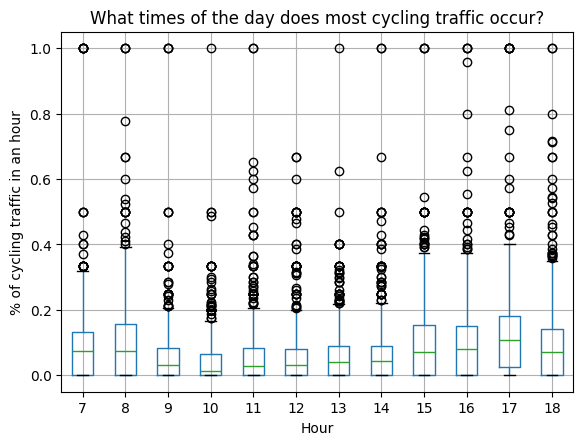

In [22]:
# create the boxplots

fig, axis = plt.subplots()
 
cycling_daily_hourly.boxplot(
    column="hourly_pct",
    by="hour",
    ax=axis)
 
axis.set(
    xlabel="Hour",
    ylabel= "% of cycling traffic in an hour",
    title="What times of the day does most cycling traffic occur?"
)
 
plt.suptitle(None)
 
plt.show()

In [23]:
# a function to calculate the highest hour for a given group, i.e., a single location ID, then uses it to create a dataset with one row per 
# location ID containing the hour in which cycling traffic was highest in the last recorded measurement year

def get_highest_hour(rows):
    if rows["Pedal_cycles"].min() == rows["Pedal_cycles"].max():
        return np.NaN
    
    return (
        rows
        .sort_values(by=["Pedal_cycles", "hour"], ascending=[False, True])
        .head(1)
        ["hour"]
        .values[0]
    )
 
highest_hours = (
    cycling_daily_hourly
    .groupby("Count_point_id")
    .apply(get_highest_hour)
)
 
highest_hours.head()

Count_point_id
900056    17.0
919150    17.0
930188    18.0
931832    16.0
931837     8.0
dtype: float64

In [24]:
# cases where we need a tie-break because the highest cycling traffic occurred in multiple hours

cycling_daily_hourly[cycling_daily_hourly["Count_point_id"] == 941463]

,Count_point_id,Count_date,hour,Pedal_cycles,TotalDailyCount,hourly_pct
1476,941463,2019-09-10,7,8,53,0.150943
1477,941463,2019-09-10,8,10,53,0.188679
1478,941463,2019-09-10,9,3,53,0.056604
1479,941463,2019-09-10,10,4,53,0.075472
1480,941463,2019-09-10,11,1,53,0.018868
1481,941463,2019-09-10,12,1,53,0.018868
1482,941463,2019-09-10,13,2,53,0.037736
1483,941463,2019-09-10,14,2,53,0.037736
1484,941463,2019-09-10,15,3,53,0.056604
1485,941463,2019-09-10,16,10,53,0.188679


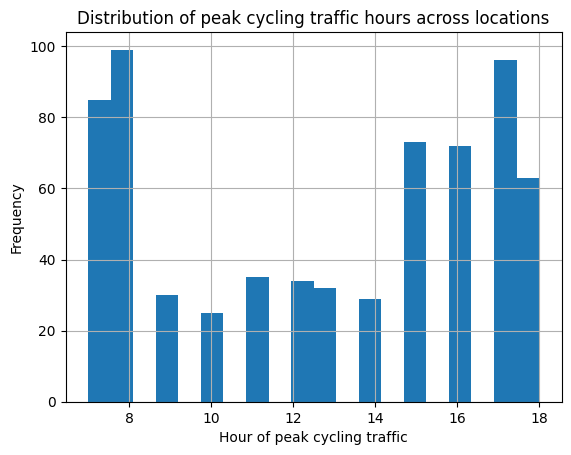

In [25]:
# look at the distribution of the busiest hours, we will be able to see at what time most locations have their cycling traffic peaks.

fig, axis = plt.subplots()
 
highest_hours.hist(bins=20, ax=axis)
 
axis.set(
    xlabel="Hour of peak cycling traffic",
    ylabel="Frequency",
    title="Distribution of peak cycling traffic hours across locations"
)
 
plt.show()

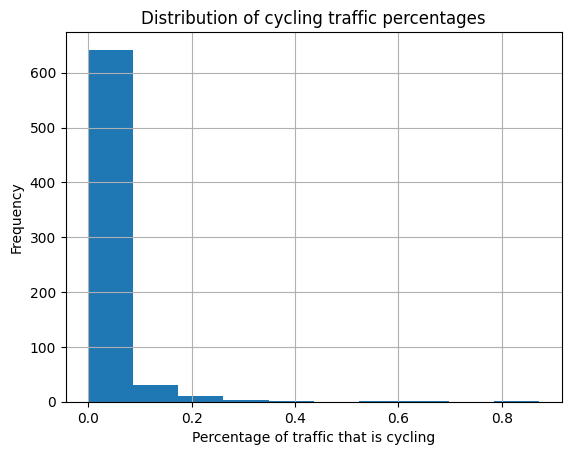

In [26]:
#  where the majority of the data lies

fig, axis = plt.subplots()
 
annual_bike_traffic["pct_cycles"].hist(bins=10, ax=axis)
 
axis.set(
    xlabel="Percentage of traffic that is cycling",
    ylabel="Frequency",
    title="Distribution of cycling traffic percentages"
)
 
plt.show()

In [27]:
# This histogram shows us that most locations have under 10% of their traffic due to cycling. That feels like a good 
# cutoff to distinguish areas of “significant” cycling traffic. The following code implements this filter and creates a filtered list of location IDs

BIKE_PERCENTAGE_CUTOFF = 0.1
 
highest_cycling = (
    annual_bike_traffic
    [annual_bike_traffic["pct_cycles"] >= BIKE_PERCENTAGE_CUTOFF]
    .reset_index()
    ["Count_point_id"]
    .to_list()
)
 
print(len(highest_cycling))
 
highest_cycling[:10]

38


[942489,
 945923,
 941061,
 945955,
 944077,
 945393,
 931932,
 941045,
 946765,
 942487]

In [28]:
# ocations that had at least a Y% increase in cycling between the first and last dates we measured

DIFF_CUTOFF = 0.5
 
biggest_increases = (
    cycling_diffs
    [(cycling_diffs["diff_pct"] >= DIFF_CUTOFF)
     & (np.isinf(cycling_diffs["diff_pct"]) == False)]
    .index
    .to_list()
)
 
print(len(biggest_increases))
 
print(biggest_increases[:10])

230
[931837, 931870, 931872, 931873, 931883, 931910, 940023, 940085, 940091, 940135]


In [29]:
# create a third list of locations, which will be locations where the highest commuting time is either 8 am-9 am or 5 pm-6 pm. 

highest_commuting = (
    highest_hours
    .loc[lambda x: x.isin([8, 17])]
    .index
    .to_list()
)
 
print(len(highest_commuting))
 
print(highest_commuting[:10])

195
[900056, 919150, 931837, 931870, 931910, 940007, 940023, 940047, 940091, 940205]


In [30]:
# code converts our lists to sets and performs the intersection of all three to discover whether there are any overlaps

top_cycling_locations = (
    # convert the first list to a set
    set(highest_cycling)
    # find the intersection between two of the sets
    .intersection(set(biggest_increases))
    # find the intersection between this result and the third set
    .intersection(set(highest_commuting))
)
 
print(len(top_cycling_locations))
 
print(top_cycling_locations)

11
{945955, 941061, 944713, 943405, 942957, 942735, 943471, 942739, 942899, 967549, 946751}


In [31]:
# understand what locations they relate to

LOCATION_COLUMNS = ['Count_point_id', 'Region_name',
                    'Region_ons_code', 'Local_authority_id',
                    'Local_authority_name', 'Local_authority_code',
                    'Road_name', 'Road_category', 'Road_type']
 
(
    traffic[traffic["Count_point_id"].isin(top_cycling_locations)]
    .drop_duplicates(subset=["Count_point_id"])
    [LOCATION_COLUMNS]
    .sort_values(["Region_name", "Local_authority_name"])
)

,Count_point_id,Region_name,Region_ons_code,Local_authority_id,Local_authority_name,Local_authority_code,Road_name,Road_category,Road_type
91927,941061,East of England,E12000006,97,Cambridgeshire,E10000003,U,MCU,Minor
74939,942899,London,E12000007,178,Kingston upon Thames,E09000021,U,MCU,Minor
76690,942739,London,E12000007,107,Lambeth,E09000022,U,MCU,Minor
85920,942735,London,E12000007,107,Lambeth,E09000022,C,MCU,Minor
81137,942957,London,E12000007,93,Tower Hamlets,E09000030,C,MCU,Minor
157760,943405,North East,E12000001,101,Gateshead,E08000037,U,MCU,Minor
157808,943471,North East,E12000001,170,Middlesbrough,E06000002,U,MCU,Minor
68650,944713,North West,E12000002,74,Warrington,E06000007,U,MCU,Minor
122686,967549,Scotland,S92000003,29,City of Edinburgh,S12000036,U,MCU,Minor
111148,945955,South East,E12000008,142,Oxfordshire,E10000025,U,MCU,Minor


In [32]:
# code calculates the coverage of these time series 

(
    traffic
    .query("Count_point_id in @biggest_increases")
    .groupby("Count_point_id")
    ["Year"]
    .agg(["min", "max"])
    .assign(diff=lambda df_: df_["max"] - df_["min"])
    .sort_values("diff", ascending=False)
    .head()
)

,min,max,diff
Count_point_id,,,
996188,2000,2019,19
983147,2000,2019,19
967547,2000,2019,19
967444,2000,2019,19
967514,2000,2018,18


In [33]:
# ode takes the raw data for that location and creates a single annual time series of cycling volumes for us to use

cycling_ts = (
    traffic[traffic["Count_point_id"] == 996188]
    .groupby("Year")
    ["Pedal_cycles"]
    .sum()
)
 
cycling_ts

Year
2000     3
2001     0
2002     9
2003     6
2004     1
2005     9
2006     1
2007     4
2008     6
2009     6
2010     6
2011     7
2012     5
2013    16
2014     7
2015    11
2016    16
2017    10
2018    10
2019    15
Name: Pedal_cycles, dtype: int64

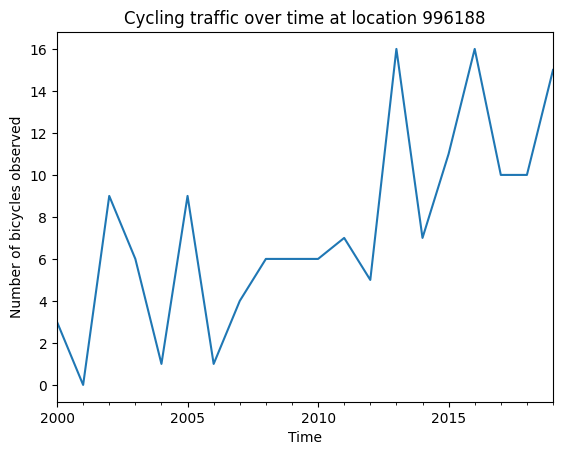

In [34]:
# the index of the series is an integer, whereas to make time series manipulation easier, it should be a date. The following code fixes

cycling_ts.index = pd.to_datetime(cycling_ts.index, format='%Y')
 
fig, axis = plt.subplots()
 
cycling_ts.plot(ax=axis)
 
axis.set(
    xlabel="Time",
    ylabel="Number of bicycles observed",
    title="Cycling traffic over time at location 996188"
)
 
plt.show()

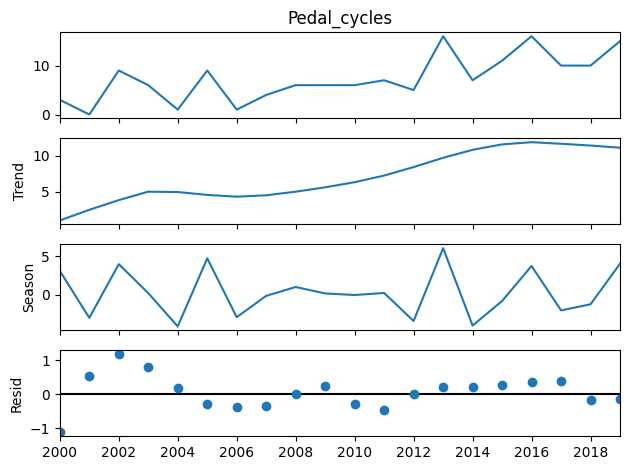

In [35]:
# he decomposition plot

from statsmodels.tsa.seasonal import STL
 
stl = STL(cycling_ts, period=2, seasonal=3)
result = stl.fit()
 
result.plot();

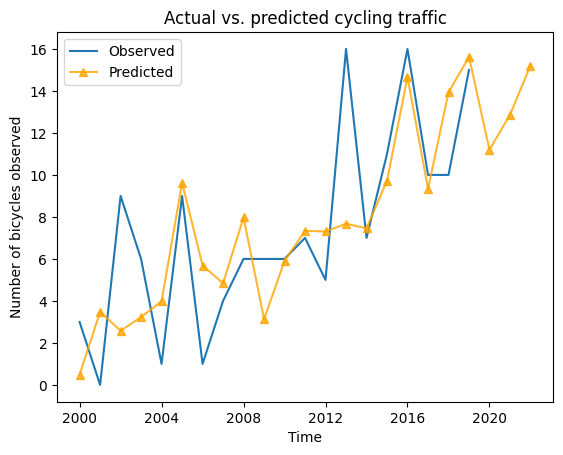

In [36]:
# calculates the best ARIMA model on the available data and then plots its predicted values against the observed values

import pmdarima as pm
 
model = pm.auto_arima(cycling_ts, seasonal=False)
 
training_predictions = model.predict_in_sample()
forecast = model.predict(3)
 
predictions = pd.concat(
    [training_predictions,
     forecast]
)
 
fig, axis = plt.subplots()
 
axis.plot(cycling_ts, label="Observed")
axis.plot(predictions,
          label="Predicted",
          marker="^",
          color="orange",
          alpha=0.8)
 
axis.set(
    xlabel="Time",
    ylabel="Number of bicycles observed",
    title="Actual vs. predicted cycling traffic"
)
 
axis.legend()
 
plt.show()